Homework 3 - 2c

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

For part a LIF:

In [69]:
delta = 1e-3
phi_vals = np.linspace(0,0.999,200)
Delta = np.log(3)

# Unperturbed voltage
def v(t):
    return 1.5 - (1.5)*np.exp(-t)

# LIF differential equation
def lif(t, v):
    return -v[0] + 1.5

# Detect threshold
def threshold(t, v):
    return v[0] - 1

threshold.direction = 0
threshold.terminal = True


Tprime = []

for phi in phi_vals:

    # Time at which perturbation occurs
    t_kick = phi * Delta

    # Voltage at that phase
    v0 = v(t_kick)

    # Apply small perturbation
    v0 = v0 + delta

    # Integrate from perturbation until threshold
    
    if v0>= 1:
        Tprime.append(t_kick)
    else:
        sol = solve_ivp(lif,[t_kick, t_kick + Delta],[v0],events=threshold,rtol=1e-10,atol=1e-12)
        if len(sol.t_events[0]) > 0:
            Tprime.append(sol.t_events[0][0])
        else:
            Tprime.append(np.nan)

    

Tprime = np.array(Tprime)

# Numerical PRC
R_num = (Delta - Tprime) / (delta*Delta)

In [73]:
Rt = (np.exp(phi_vals*Delta)/(Delta*1.5))

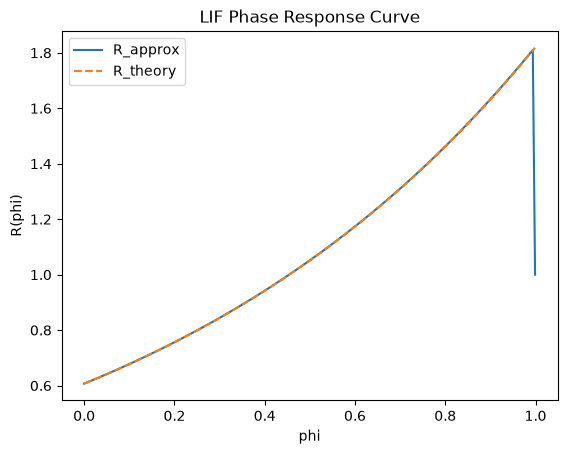

In [81]:
plt.title('LIF Phase Response Curve')
plt.plot(phi_vals, R_num,label='R_approx')
plt.plot(phi_vals,Rt, linestyle = '--',label = 'R_theory')
plt.xlabel('phi')
plt.ylabel('R(phi)')
plt.legend()
plt.show()

The LIF PRC is Type I because all of the R(phi) is greater than 0. This means that a small positive perturbation always advances the next spike in the phase. 

For the part with the FitzHugh-Nagumo oscillator

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def sys(t, y):
    v, w = y

    dv = v - v**3/3 - w + 0.5
    dw = 0.08*(v + 0.7 - 0.8*w)

    return [dv, dw]


# Find the limit cycle
def upward_crossing(t, y):
    return y[0]

upward_crossing.direction = 1
upward_crossing.terminal = False

sol = solve_ivp(sys,[0, 1000],[-1, -0.5],events=upward_crossing,dense_output=True,rtol=1e-10,atol=1e-12,max_step=0.02)

# Last two upward crossings
spikes = sol.t_events[0]

Delta = spikes[-1] - spikes[-2]

# State at beginning of one cycle
y0 = sol.y_events[0][-2]

# Integrate exactly one cycle
cycle = solve_ivp(sys,[0, Delta],y0,dense_output=True,rtol=1e-10,atol=1e-12,max_step=0.01)

delta = 1e-3

phis = np.linspace(0, 0.999, 500)
R = []

for phi in phis:

    # State at phase phi
    y = cycle.sol(phi*Delta).copy()

    # Apply voltage kick
    y[0] += delta

    def next_spike(t, y):
        return y[0]

    next_spike.direction = 1
    next_spike.terminal = True

    perturbed = solve_ivp(sys,[0, Delta + 10],y,events=next_spike,rtol=1e-9,atol=1e-11,max_step=0.03)

    # Time from the kick to the next spike
    waiting_time = perturbed.t_events[0][0]

    # Time of spike measured from beginning of cycle
    Tprime = phi*Delta + waiting_time

    R.append((Delta - Tprime)/delta)

R = np.array(R)

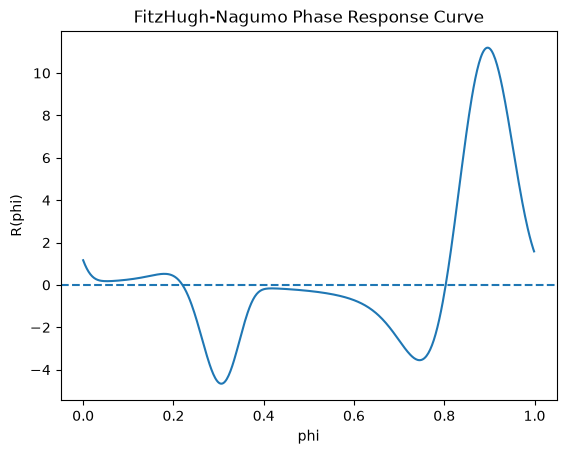

In [88]:
plt.plot(phis, R)
plt.axhline(0, linestyle='--')
plt.xlabel('phi')
plt.ylabel('R(phi)')
plt.title('FitzHugh-Nagumo Phase Response Curve')
plt.show()

In [92]:
R.min()

np.float64(-4.661619096566483)

In [93]:
R.max()

np.float64(11.195698495725992)

In [94]:
Delta

np.float64(39.47441498023909)

The period is 39.47, the min of R is -4.66, and the max of R is 11.20.

The FitzHugh-Nagumo PRC is Type II because it has both positive and negative regions (lobes) in its PRC. A negative lobe means that the small positive pertubation/kick delayed the next spike in the phase. 

R < 0 when phi is approximatly between 0.2-0.8 just reading off the graph